In [1]:
# ============================================
# BANK CHURN ANALYTICS - Day 10
# K-Means Clustering & Customer Personas
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
df = pd.read_csv(r'D:\Python project\data\European_Bank_Cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (10000, 19)


In [3]:
# Select features for clustering
cluster_features = ['Age', 'Balance', 'NumOfProducts', 
                    'IsActiveMember', 'EstimatedSalary',
                    'Tenure', 'CreditScore', 'CLV_Score',
                    'EngagementScore']

X = df[cluster_features].copy()

# Scale features — CRITICAL for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
for f in cluster_features:
    print(f"  → {f}")
print(f"\nScaled array shape: {X_scaled.shape}")

Features selected for clustering:
  → Age
  → Balance
  → NumOfProducts
  → IsActiveMember
  → EstimatedSalary
  → Tenure
  → CreditScore
  → CLV_Score
  → EngagementScore

Scaled array shape: (10000, 9)


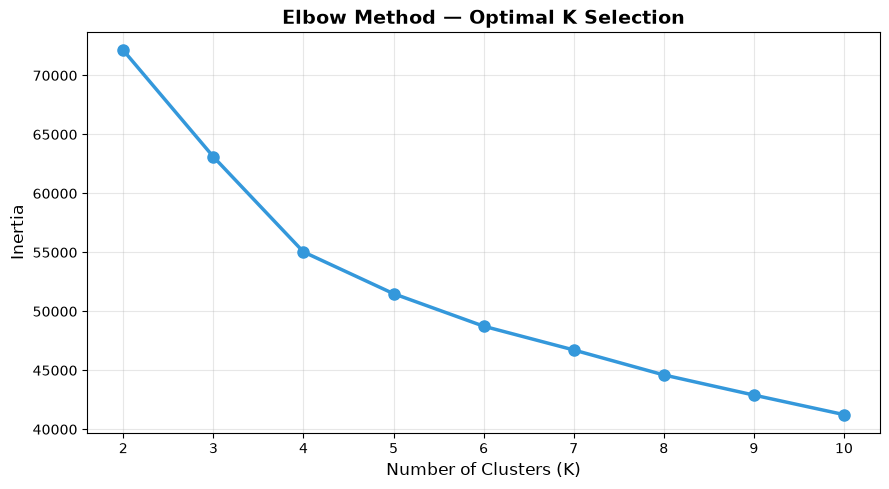

Chart saved!


In [4]:
# ELBOW METHOD — Find optimal K
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, inertias, 'bo-', linewidth=2.5, 
        markersize=8, color='#3498db')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Optimal K Selection', 
              fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\20_elbow_method.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

K=2 | Silhouette Score: 0.2008
K=3 | Silhouette Score: 0.1785
K=4 | Silhouette Score: 0.2053
K=5 | Silhouette Score: 0.2065
K=6 | Silhouette Score: 0.1881
K=7 | Silhouette Score: 0.1762
K=8 | Silhouette Score: 0.1788
K=9 | Silhouette Score: 0.1697
K=10 | Silhouette Score: 0.1738


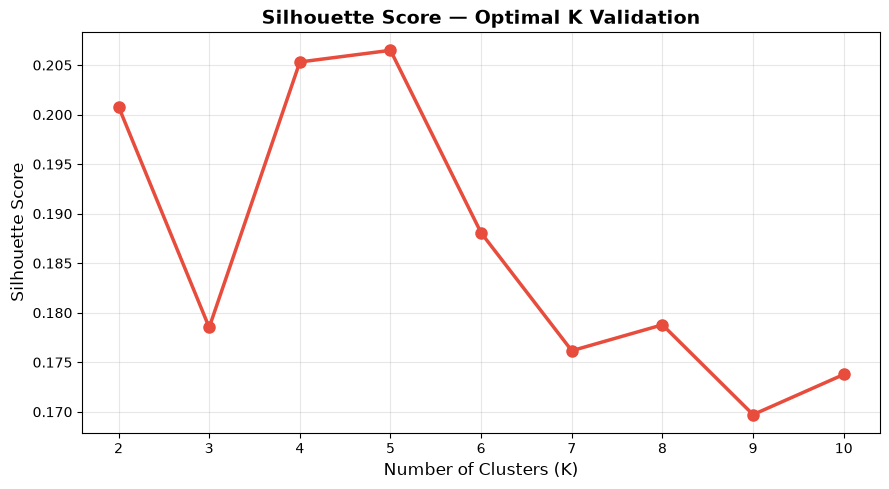


Best K: 5


In [5]:
# SILHOUETTE SCORE — Validate optimal K
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, silhouette_scores, 'bo-', linewidth=2.5,
        markersize=8, color='#e74c3c')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score — Optimal K Validation',
              fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\21_silhouette_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nBest K:", k_range[silhouette_scores.index(max(silhouette_scores))])

In [4]:
# TRAIN FINAL K-MEANS MODEL (K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means trained with K={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Churn rate per cluster
print(f"\nChurn rate per cluster:")
cluster_churn = df.groupby('Cluster')['Exited'].agg(['mean', 'count', 'sum'])
cluster_churn.columns = ['ChurnRate', 'Total', 'Churned']
cluster_churn['ChurnRate'] = (cluster_churn['ChurnRate'] * 100).round(2)
print(cluster_churn)

K-Means trained with K=4

Cluster distribution:
Cluster
0    3024
1    2127
2    1918
3    2931
Name: count, dtype: int64

Churn rate per cluster:
         ChurnRate  Total  Churned
Cluster                           
0            15.94   3024      482
1            11.89   2127      253
2            20.23   1918      388
3            31.18   2931      914
